# 실험 3: Joint Diffusion, DDPM 300스텝 생성

In [1]:
import os
import subprocess

GPU_ID = None  # None이면 아래에서 가장 한가한 GPU를 자동 선택. 고정하려면 "0" / "1" / "2"처럼 지정


def pick_free_gpu():
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=index,memory.used,utilization.gpu", "--format=csv,noheader,nounits"]
    ).decode()
    rows = [tuple(int(v) for v in line.split(",")) for line in out.strip().splitlines()]
    for idx, mem, util in rows:
        print(f"  GPU {idx}: memory {mem} MiB, util {util}%")
    return str(min(rows, key=lambda r: (r[1], r[2]))[0])


if GPU_ID is None:
    GPU_ID = pick_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID
print("사용 GPU:", GPU_ID)
RUN_SEEDS = list(range(10))  # seed 0~9 전부

  GPU 0: memory 12945 MiB, util 100%
  GPU 1: memory 3 MiB, util 0%
  GPU 2: memory 0 MiB, util 0%
사용 GPU: 2


## 0. 라이브러리 & 공통 유틸 / 모델 정의

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
if ".." not in sys.path:
    sys.path.insert(0, "..")

import os
import time
from collections import Counter

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from models import Unet, Classifier
from utils import (
    set_seed, DEVICE, SEEDS, EMA,
    evaluate_classifier, metrics_to_rows, append_result_rows,
)
from diffusion import GaussianDiffusion
from data import (
    build_imbalanced_split, CachedDataset, CachedSubset,
    generate_fill_batch,
)

SEEDS = [s for s in SEEDS if s in RUN_SEEDS]

print("device:", DEVICE)
print("모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, diffusion.py, data.py)")


site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, diffusion.py, data.py)


## 1. 데이터 생성: 불균형 데이터셋

In [4]:
image_size = 64
channels = 3
batch_size = 40
num_classes = 3

data_root = os.environ.get("DATA_ROOT", "../../data/256")

RESULTS_CSV = "exp3_joint_step_300.csv"
if os.path.exists(RESULTS_CSV):
    os.remove(RESULTS_CSV)

CLASS_NAMES = ["Normal", "Underfill_50FR", "Underfill_Fan"]  # ImageFolder는 폴더명 알파벳순으로 라벨을 매김 (Normal=0, Underfill_50FR=1, Underfill_Fan=2)

train_counts = {0: 800, 1: 80, 2: 80}
test_counts = {0: 100, 1: 100, 2: 100}

transform = T.Compose([
    T.Resize((image_size, image_size)),
    T.ToTensor(),
    T.Lambda(lambda t: (t * 2) - 1),  # [0,1] -> [-1,1]
])

full_dataset = ImageFolder(root=data_root, transform=transform)
assert full_dataset.classes == CLASS_NAMES, full_dataset.classes

full_cached = CachedDataset(full_dataset)


def set_split(seed):
    global train_indices, test_indices, train_dataset, test_dataset
    global train_loader, test_loader, train_labels, test_labels
    train_indices, test_indices = build_imbalanced_split(full_dataset, train_counts, test_counts, seed=seed)

    train_dataset = CachedSubset(full_cached, train_indices)
    test_dataset = CachedSubset(full_cached, test_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                               pin_memory=(DEVICE == "cuda"))
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                              pin_memory=(DEVICE == "cuda"))

    train_labels = [full_dataset.samples[i][1] for i in train_indices]
    test_labels = [full_dataset.samples[i][1] for i in test_indices]


set_split(0)  # 미리보기/학습량 기준(BASELINE_STEPS) 계산용 초기 분할
print("SEEDS:", SEEDS)
print("Train label distribution:", Counter(train_labels))
print("Test  label distribution:", Counter(test_labels))


SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Train label distribution: Counter({0: 800, 1: 80, 2: 80})
Test  label distribution: Counter({0: 100, 1: 100, 2: 100})


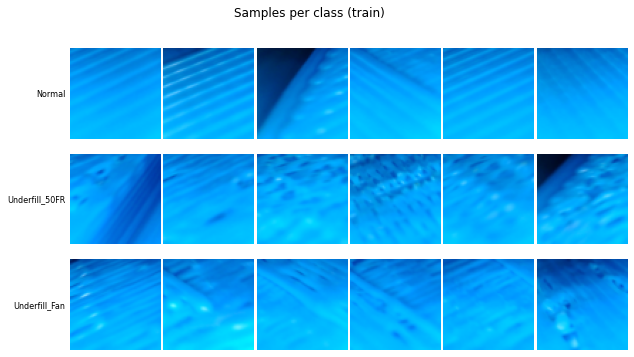

In [5]:
def denorm(x):
    return (x + 1) / 2

W, L, R = 9, 0.13, 0.99
cell = W * (R - L) / 6
H = num_classes * cell + 0.6
fig, axes = plt.subplots(num_classes, 6, figsize=(W, H))
for cls in range(num_classes):
    idxs = [i for i, y in enumerate(train_labels) if y == cls][:6]
    for j, idx in enumerate(idxs):
        img, _ = train_dataset[idx]
        axes[cls, j].imshow(denorm(img).permute(1, 2, 0).numpy())
        axes[cls, j].axis("off")
    axes[cls, 0].text(-0.05, 0.5, CLASS_NAMES[cls], transform=axes[cls, 0].transAxes,
                      ha="right", va="center", fontsize=8)
plt.suptitle("Samples per class (train)")
plt.subplots_adjust(left=L, right=R, bottom=0.05 / H, top=1 - 0.55 / H, wspace=0.03, hspace=0.03)
plt.show()

## 2. Diffusion / 평가 공통 유틸

In [ ]:
timesteps = 300
ddpm = GaussianDiffusion(timesteps=timesteps, image_size=image_size, channels=channels)

print("diffusion/평가 유틸 정의 완료")


CLASSIFIER_EPOCHS_REF = 50
BASELINE_STEPS = len(train_loader) * CLASSIFIER_EPOCHS_REF
print(f"분류기 학습 기준 step 수 (BASELINE_STEPS) = {len(train_loader)} batches/epoch "
      f"x {CLASSIFIER_EPOCHS_REF} epochs = {BASELINE_STEPS}")

DIFFUSION_EPOCHS_REF = 700
EMA_DECAY = 0.999


diffusion/평가 유틸 정의 완료
분류기 학습 기준 step 수 (BASELINE_STEPS) = 24 batches/epoch x 50 epochs = 1200


## 실험 3: Joint Diffusion (사전학습 + 손실 공유)

In [9]:
def pretrain_diffusion_for_joint(seed, epochs=None):
    epochs = epochs or DIFFUSION_EPOCHS_REF
    set_seed(seed)
    device = DEVICE

    diffusion = Unet(dim=32, channels=channels, num_classes=num_classes).to(device)
    opt_g = torch.optim.Adam(diffusion.parameters(), lr=2e-4)
    diffusion_loss_fn = nn.MSELoss()
    ema = EMA(diffusion, decay=EMA_DECAY)
    t0 = time.time()

    pbar = tqdm(range(epochs), desc=f"[Joint-Pretrain seed{seed}]")
    for epoch in pbar:
        diffusion.train()
        epoch_losses = []
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            t = torch.randint(0, timesteps, (x.size(0),), device=device)
            noise = torch.randn_like(x)
            x_noisy = ddpm.q_sample(x, t, noise)
            pred_noise = diffusion(x_noisy, t, y)
            loss = diffusion_loss_fn(pred_noise, noise)

            opt_g.zero_grad()
            loss.backward()
            opt_g.step()
            ema.update(diffusion)

            epoch_losses.append(loss.item())

        pbar.set_postfix(diff=f"{np.mean(epoch_losses):.4f}")

        if (epoch + 1) % 100 == 0 or epoch == epochs - 1:
            tqdm.write(f"[Joint-Pretrain seed{seed}] Epoch {epoch+1}/{epochs} Diff={np.mean(epoch_losses):.4f} "
                  f"elapsed={time.time()-t0:.1f}s")

    return diffusion, ema

pretrain_epochs = max(0, DIFFUSION_EPOCHS_REF - CLASSIFIER_EPOCHS_REF)

PRETRAINED_PATH = "exp3_pretrained_seed{seed}.pt"
PRETRAINED_EMA_PATH = "exp3_pretrained_ema_seed{seed}.pt"

pretrained_diffusion_models = {}
pretrained_emas = {}
pretrain_elapsed = {}
for seed in SEEDS:
    set_split(seed)  # seed마다 train/test 분할을 새로 뽑는다 (학습 전에 반드시 먼저)
    path, ema_path = PRETRAINED_PATH.format(seed=seed), PRETRAINED_EMA_PATH.format(seed=seed)
    if os.path.exists(path) and os.path.exists(ema_path):
        diffusion = Unet(dim=32, channels=channels, num_classes=num_classes).to(DEVICE)
        diffusion.load_state_dict(torch.load(path, map_location=DEVICE))
        ema = EMA(diffusion, decay=EMA_DECAY)
        ema.model.load_state_dict(torch.load(ema_path, map_location=DEVICE))
        ema.num_updates = pretrain_epochs * len(train_loader)
        pretrained_diffusion_models[seed], pretrained_emas[seed] = diffusion, ema
        pretrain_elapsed[seed] = 0.0
        print(f"[Joint-Pretrain seed{seed}] 사전학습 건너뜀: {path}, {ema_path} 로드")
        continue

    print(f"\n===== Joint Diffusion Pretraining | Seed {seed} =====")
    t0 = time.time()
    pretrained_diffusion_models[seed], pretrained_emas[seed] = pretrain_diffusion_for_joint(seed, epochs=pretrain_epochs)
    pretrain_elapsed[seed] = time.time() - t0
    print(f"[Joint-Pretrain seed{seed}] 사전학습 소요 시간: {pretrain_elapsed[seed]:.1f}초")
    torch.save(pretrained_diffusion_models[seed].state_dict(), PRETRAINED_PATH.format(seed=seed))
    torch.save(pretrained_emas[seed].model.state_dict(), PRETRAINED_EMA_PATH.format(seed=seed))



===== Joint Diffusion Pretraining | Seed 0 =====


[Joint-Pretrain seed0]:  15%|█▌        | 100/650 [05:02<27:44,  3.03s/it, diff=0.0059]

[Joint-Pretrain seed0] Epoch 100/650 Diff=0.0059 elapsed=302.0s


[Joint-Pretrain seed0]:  31%|███       | 200/650 [10:03<22:38,  3.02s/it, diff=0.0043]

[Joint-Pretrain seed0] Epoch 200/650 Diff=0.0043 elapsed=603.8s


...

[Joint-Pretrain seed9] Epoch 500/650 Diff=0.0033 elapsed=1492.4s


[Joint-Pretrain seed9]:  92%|█████████▏| 600/650 [29:50<02:29,  2.98s/it, diff=0.0028]

[Joint-Pretrain seed9] Epoch 600/650 Diff=0.0028 elapsed=1790.9s


[Joint-Pretrain seed9]: 100%|██████████| 650/650 [32:20<00:00,  2.98s/it, diff=0.0026]

[Joint-Pretrain seed9] Epoch 650/650 Diff=0.0026 elapsed=1940.2s
[Joint-Pretrain seed9] 사전학습 소요 시간: 1940.4초


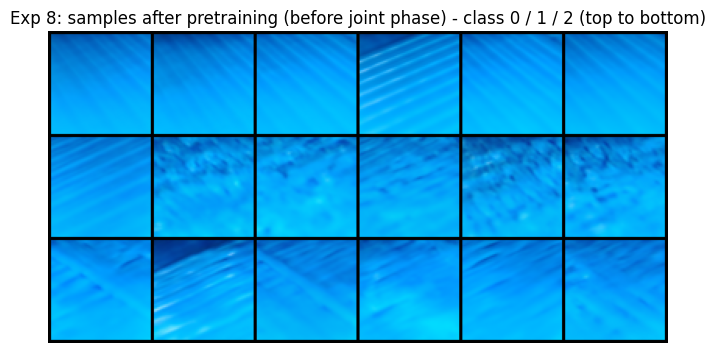

In [10]:
seed_to_show = SEEDS[0]
diffusion_pretrained = pretrained_emas[seed_to_show].model  # EMA 가중치로 샘플링
y_vis = torch.tensor([0] * 6 + [1] * 6 + [2] * 6, device=DEVICE)
x_vis_pretrained = ddpm.sample_ddpm(diffusion_pretrained, y_vis, DEVICE)
grid = make_grid(denorm(x_vis_pretrained).clamp(0, 1).cpu(), nrow=6)
plt.figure(figsize=(8, 4.5))
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Exp 3: samples after pretraining (before joint phase) - class 0 / 1 / 2 (top to bottom)")
plt.show()


In [11]:
def run_joint_diffusion(seed, diffusion, ema, epochs=None, minority_classes=(1, 2),
                         lambda_shared_max=0.01, shared_cap=16, shared_t_max=90):

    epochs = epochs or CLASSIFIER_EPOCHS_REF
    set_seed(seed)
    device = DEVICE

    classifier = Classifier(num_classes=num_classes, img_channels=channels).to(device)

    opt_g = torch.optim.Adam(diffusion.parameters(), lr=2e-4)
    opt_c = torch.optim.Adam(classifier.parameters(), lr=1e-3)

    diffusion_loss_fn = nn.MSELoss()
    cls_loss_fn = nn.CrossEntropyLoss()
    t0 = time.time()

    pbar = tqdm(range(epochs), desc=f"[Joint seed{seed}]")
    for epoch in pbar:
        lambda_shared = lambda_shared_max * (epoch / max(1, epochs - 1))

        diffusion.train()
        classifier.train()

        epoch_diff_losses, epoch_cls_losses = [], []

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            x_fake, y_fake = generate_fill_batch(ddpm, ema.model, y, device, minority_classes)

            t = torch.randint(0, timesteps, (x.size(0),), device=device)
            noise = torch.randn_like(x)
            x_noisy = ddpm.q_sample(x, t, noise)
            pred_noise = diffusion(x_noisy, t, y)
            loss_diff = diffusion_loss_fn(pred_noise, noise)

            opt_g.zero_grad()
            loss_diff.backward()

            if lambda_shared > 0 and x_fake is not None:
                n_shared = min(shared_cap, x_fake.size(0))
                shared_idx = torch.randperm(x_fake.size(0), device=device)[:n_shared]
                x_src, y_shared = x_fake[shared_idx], y_fake[shared_idx]
                t_shared = torch.randint(0, shared_t_max, (n_shared,), device=device)
                x_t_shared = ddpm.q_sample(x_src, t_shared)
                eps_shared = diffusion(x_t_shared, t_shared, y_shared)
                x_shared = ddpm.predict_x0(x_t_shared, t_shared, eps_shared).clamp(-1.0, 1.0)
                logits_shared_g = classifier(x_shared)
                loss_shared_g = cls_loss_fn(logits_shared_g, y_shared)

                (lambda_shared * loss_shared_g).backward()
            else:
                loss_shared_g = torch.tensor(0.0, device=device)

            if x_fake is not None:
                x_batch = torch.cat([x, x_fake], dim=0)
                y_batch = torch.cat([y, y_fake], dim=0)
            else:
                x_batch, y_batch = x, y

            logits_balanced = classifier(x_batch)
            loss_cls_balanced = cls_loss_fn(logits_balanced, y_batch)

            opt_c.zero_grad()
            loss_cls_balanced.backward()

            opt_g.step()
            opt_c.step()
            ema.update(diffusion)

            epoch_diff_losses.append(loss_diff.item())
            epoch_cls_losses.append(loss_cls_balanced.item())

        pbar.set_postfix(diff=f"{np.mean(epoch_diff_losses):.4f}", cls=f"{np.mean(epoch_cls_losses):.4f}",
                         lam=f"{lambda_shared:.4f}")

        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            tqdm.write(f"[Joint seed{seed}] Epoch {epoch+1}/{epochs} "
                  f"Diff={np.mean(epoch_diff_losses):.4f} Cls={np.mean(epoch_cls_losses):.4f} "
                  f"λ_shared={lambda_shared:.3f} elapsed={time.time()-t0:.1f}s")

    metrics = evaluate_classifier(classifier, test_loader, device, num_classes, CLASS_NAMES)
    return metrics, diffusion, ema, classifier


joint_rows = []
joint_diffusion_models = {}

for seed in SEEDS:
    set_split(seed)  # seed마다 train/test 분할을 새로 뽑는다 (학습 전에 반드시 먼저)
    print(f"\n===== Joint Diffusion | Seed {seed} =====")
    t0 = time.time()
    metrics, diffusion_joint, ema_joint, classifier_joint = run_joint_diffusion(
        seed, pretrained_diffusion_models[seed], pretrained_emas[seed])
    joint_elapsed = time.time() - t0
    total_elapsed = pretrain_elapsed[seed] + joint_elapsed
    print(f"[Joint seed{seed}] joint 단계 소요 시간: {joint_elapsed:.1f}초 "
          f"(사전학습 {pretrain_elapsed[seed]:.1f}초 포함 총 {total_elapsed:.1f}초)")

    joint_diffusion_models[seed] = ema_joint.model  # 미리보기는 EMA 가중치로

    rows = metrics_to_rows(metrics, seed, "exp3_joint_step_300")
    joint_rows.extend(rows)
    append_result_rows(rows, RESULTS_CSV)

df_joint = pd.DataFrame(joint_rows)
df_joint



===== Joint Diffusion | Seed 0 =====


[Joint seed0]:  10%|█         | 5/50 [39:23<5:54:34, 472.77s/it, cls=0.8724, diff=0.0021, lam=0.0008]

[Joint seed0] Epoch 5/50 Diff=0.0021 Cls=0.8724 λ_shared=0.001 elapsed=2363.2s


[Joint seed0]:  20%|██        | 10/50 [1:18:47<5:15:37, 473.44s/it, cls=0.6502, diff=0.0022, lam=0.0018]

[Joint seed0] Epoch 10/50 Diff=0.0022 Cls=0.6502 λ_shared=0.002 elapsed=4728.0s


...

[Joint seed9]:  90%|█████████ | 45/50 [5:51:48<39:05, 469.15s/it, cls=0.0814, diff=0.0023, lam=0.0090]  

[Joint seed9] Epoch 45/50 Diff=0.0023 Cls=0.0814 λ_shared=0.009 elapsed=21108.3s


[Joint seed9]: 100%|██████████| 50/50 [6:30:54<00:00, 469.08s/it, cls=0.0719, diff=0.0024, lam=0.0100]

[Joint seed9] Epoch 50/50 Diff=0.0024 Cls=0.0719 λ_shared=0.010 elapsed=23454.0s
===== Evaluation =====
Accuracy        : 0.7600
Precision(macro): 0.8307
Recall(macro)   : 0.7600
F1(macro)       : 0.7574

Per-class:
Class Normal | P:0.607 R:0.990 F1:0.753 N:100
Class Underfill_50FR | P:0.946 R:0.530 F1:0.679 N:100
Class Underfill_Fan | P:0.938 R:0.760 F1:0.840 N:100

Confusion Matrix:
 [[99  1  0]
 [42 53  5]
 [22  2 76]]
[Joint seed9] joint 단계 소요 시간: 23454.0초 (사전학습 1940.4초 포함 총 25394.5초)


,method,seed,class,precision,recall,f1,support,accuracy
0,8_joint_diffusion_ddpm300,0,0,0.717742,0.890000,0.794643,100,0.760000
1,8_joint_diffusion_ddpm300,0,1,0.975610,0.400000,0.567376,100,0.760000
2,8_joint_diffusion_ddpm300,0,2,0.733333,0.990000,0.842553,100,0.760000
3,8_joint_diffusion_ddpm300,0,macro,0.808895,0.760000,0.734857,300,0.760000
4,8_joint_diffusion_ddpm300,1,0,0.627451,0.960000,0.758893,100,0.786667
5,8_joint_diffusion_ddpm300,1,1,0.932203,0.550000,0.691824,100,0.786667
6,8_joint_diffusion_ddpm300,1,2,0.965909,0.850000,0.904255,100,0.786667
7,8_joint_diffusion_ddpm300,1,macro,0.841854,0.786667,0.784991,300,0.786667
8,8_joint_diffusion_ddpm300,2,0,0.612903,0.950000,0.745098,100,0.763333
9,8_joint_diffusion_ddpm300,2,1,0.912281,0.520000,0.662420,100,0.763333


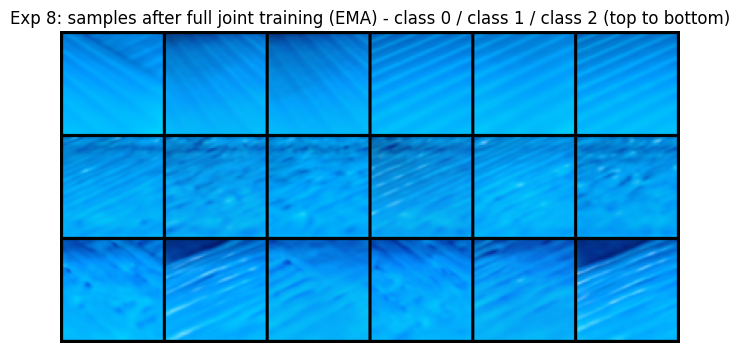

In [12]:
seed_to_show = SEEDS[0]
diffusion_joint = joint_diffusion_models[seed_to_show]
y_vis = torch.tensor([0] * 6 + [1] * 6 + [2] * 6, device=DEVICE)
x_vis_joint = ddpm.sample_ddpm(diffusion_joint, y_vis, DEVICE)
grid = make_grid(denorm(x_vis_joint).clamp(0, 1).cpu(), nrow=6)
plt.figure(figsize=(8, 4.5))
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Exp 3: samples after full joint training (EMA) - class 0 / class 1 / class 2 (top to bottom)")
plt.show()
